Best Efficiency Loss = 2.20%


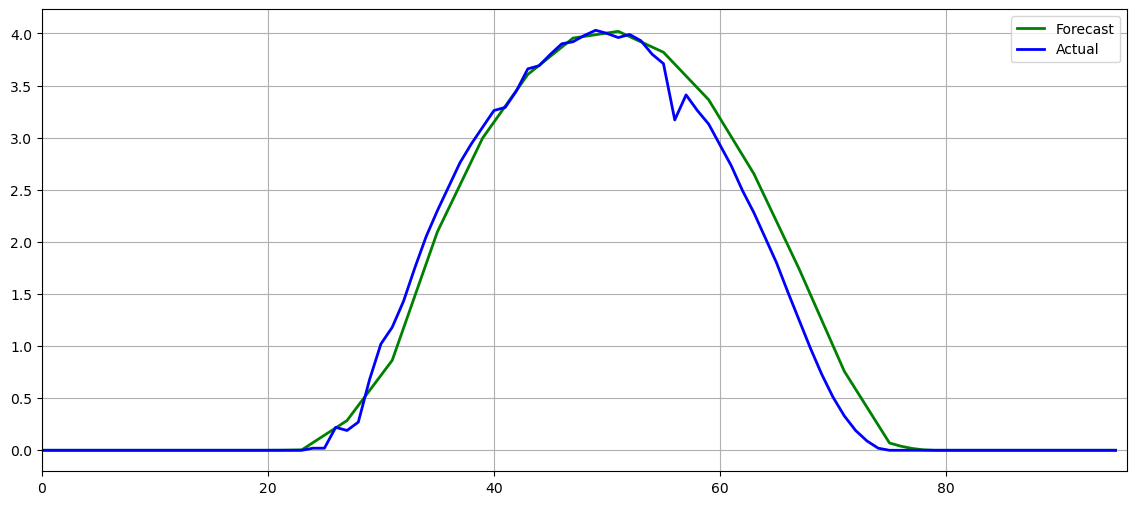

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from sklearn.metrics import mean_absolute_percentage_error

file_path = r"C:\Users\Manjot Singh\Desktop\FixedUserStory_MAL Solar Forecast using GHI_Aau.xlsx"

#Variables
type = "fixed"

if type == "fixed":
    df = pd.read_excel(file_path, sheet_name="Area & Efficiency", header=[1])
    df.columns = df.columns.str.strip()
    null_indices = df[df['Module Type'].isna()].index
    first_null_pos = df.index.get_loc(null_indices[0])
    df = df.iloc[:first_null_pos]

    df_st = pd.read_excel(file_path, sheet_name="Forecast Config", header=[8])
    lat = float(df_st.loc[0, "Lat"])

    df_tilt = pd.read_excel(file_path, sheet_name="Config Tilt Angle", header=[7])
    df_tilt.columns = df_tilt.columns.str.strip()
    null_indices = df_tilt[df_tilt['Fixed'].isna()].index
    first_null_pos = df_tilt.index.get_loc(null_indices[0])
    df_tilt = df_tilt.iloc[:first_null_pos]
    df_tilt = df_tilt.dropna(how='all', axis=1)
    df_tilt = df_tilt.rename(columns={
        'Unnamed: 2': 'Month_Num',
        'Unnamed: 3': 'Month',
    })
    month_lookup = df_tilt.set_index('Month')['Fixed'].to_dict()

    df_fix = pd.read_excel(file_path, sheet_name="Fixed", header=[1])
    df_fix.columns = df_fix.columns.str.strip()
    null_indices = df_fix[df_fix['Date'].isna()].index
    first_null_pos = df_fix.index.get_loc(null_indices[0])
    df_fix = df_fix.iloc[:first_null_pos]

    df_fix["Date"] = pd.Timestamp.today()
    first_date = pd.Timestamp.today().replace(month=1, day=1).normalize()

    df_fix["Declination Angle ∆"] = 23.45 * (
        np.sin(
            np.radians(
                360 * (284 + (df_fix["Date"] - first_date).dt.days + 1) / 365
            )
        )
    )

    df_fix["Elevation angle a"] = (90 - lat + df_fix["Declination Angle ∆"])
    df_fix["Tilt Angle b"] = df_fix["Date"].dt.strftime('%B').map(month_lookup)
    df_fix["a+b"] = df_fix["Elevation angle a"] + df_fix["Tilt Angle b"]
    df_fix["SIN(a+b)"] = np.sin(np.radians(df_fix["a+b"]))
    df_fix["Sin(a)"] = np.sin(np.radians(df_fix["Elevation angle a"]))
    df_fix["GHI*sin(a)"] = df_fix["GHI_Forecast"] * df_fix["Sin(a)"]
    df_fix["GHI*sin(a+b)"] = df_fix["GHI_Forecast"] * df_fix["SIN(a+b)"]
    df_fix["POA fixed"] = df_fix["GHI*sin(a+b)"] / df_fix["Sin(a)"]

    # Maximum possible loss
    max_loss = df["Standard PV Efficiency (%)"].min()

    #peak_error = abs(actual_peak - predicted_peak) / actual_peak * 100

    results = []

    for loss in np.arange(0, max_loss + 0.01, 0.1):

        df["Efficiency Losses(%)"] = loss
        df["Net Efficiency (%)"] = df["Standard PV Efficiency (%)"] - df["Efficiency Losses(%)"]
        df["Eff Area"] = (df["Total area(m2)"] * df["Net Efficiency (%)"]) / 100
    
        df_fix["Fixed Power=I*Ƞ*A"] = (
            df_fix["POA fixed"] * np.sum(df["Eff Area"])
        ) / 1000000

        # Peak power comparison
        actual_peak = df_fix["Actual"].max()
        predicted_peak = df_fix["Fixed Power=I*Ƞ*A"].max()

        peak_error = abs(actual_peak - predicted_peak)

        results.append({
            "Efficiency Loss (%)": loss,
            "Actual Peak": actual_peak,
            "Predicted Peak": predicted_peak,
            "Peak Error": peak_error
        })
        results_df = pd.DataFrame(results)

    # Get efficiency loss with least Peak Error
    best_loss = results_df.loc[
        results_df["Peak Error"].idxmin(),
        "Efficiency Loss (%)"
    ]

    # Assign best efficiency loss
    df["Efficiency Losses(%)"] = best_loss

    # Recalculate dependent columns
    df["Net Efficiency (%)"] = (
        df["Standard PV Efficiency (%)"] - df["Efficiency Losses(%)"]
    )

    df["Eff Area"] = (
        df["Total area(m2)"] * df["Net Efficiency (%)"]
    ) / 100

    # Recalculate final power using the best efficiency loss
    df_fix["Fixed Power=I*Ƞ*A"] = (
        df_fix["POA fixed"] * df["Eff Area"].sum()
    ) / 1_000_000

    print(f"Best Efficiency Loss = {best_loss:.2f}%")

    p = np.arange(0, 96)
    plt.figure(figsize=(14,6))
    plt.plot(p, df_fix["Fixed Power=I*Ƞ*A"], color='green', label = "Forecast", linewidth=2)
    plt.plot(p, df_fix["Actual"], color='blue', label = "Actual", linewidth=2)
    plt.xlim(0, 96)
    plt.legend()
    plt.grid(True)
    plt.show()
elif type == "tracking":
    df = pd.read_excel(file_path, sheet_name="Area & Efficiency", header=[1])
    df.columns = df.columns.str.strip()
    null_indices = df[df['Module Type'].isna()].index
    first_null_pos = df.index.get_loc(null_indices[0])
    df = df.iloc[:first_null_pos]

    df_st = pd.read_excel(file_path, sheet_name="Forecast Config", header=[8])
    lat = float(df_st.loc[0, "Lat"])

    df_tilt = pd.read_excel(file_path, sheet_name="Config Tilt Angle", header=[7])
    df_tilt.columns = df_tilt.columns.str.strip()
    null_indices = df_tilt[df_tilt['Fixed'].isna()].index
    first_null_pos = df_tilt.index.get_loc(null_indices[0])
    df_tilt = df_tilt.iloc[:first_null_pos]
    df_tilt = df_tilt.dropna(how='all', axis=1)
    df_tilt = df_tilt.rename(columns={
        'Unnamed: 2': 'Month_Num',
        'Unnamed: 3': 'Month',
    })
    #month_lookup = df_tilt.set_index('Month')['Fixed'].to_dict()

    df_fix = pd.read_excel(file_path, sheet_name="Fixed", header=[1])
    df_fix.columns = df_fix.columns.str.strip()
    df_fix["Actual"] = df_fix["Actual"].fillna(0)
    null_indices = df_fix[df_fix['Date'].isna()].index
    first_null_pos = df_fix.index.get_loc(null_indices[0])
    df_fix = df_fix.iloc[:first_null_pos]

    df_fix["Date"] = pd.Timestamp.today()
    first_date = pd.Timestamp.today().replace(month=1, day=1).normalize()

    df_fix["Declination Angle ∆"] = 23.45 * (
        np.sin(
            np.radians(
                360 * (284 + (df_fix["Date"] - first_date).dt.days + 1) / 365
            )
        )
    )

    df_fix["Elevation angle a"] = (90 - lat + df_fix["Declination Angle ∆"])
    df_fix["Tilt Angle b"] = df_fix["Date"].dt.strftime('%B').map(month_lookup)
    df_fix["a+b"] = df_fix["Elevation angle a"] + df_fix["Tilt Angle b"]
    df_fix["SIN(a+b)"] = np.sin(np.radians(df_fix["a+b"]))
    df_fix["Sin(a)"] = np.sin(np.radians(df_fix["Elevation angle a"]))
    df_fix["GHI*sin(a)"] = df_fix["GHI_Forecast"] * df_fix["Sin(a)"]
    df_fix["GHI*sin(a+b)"] = df_fix["GHI_Forecast"] * df_fix["SIN(a+b)"]
    df_fix["POA fixed"] = df_fix["GHI*sin(a+b)"] / df_fix["Sin(a)"]

    # Maximum possible loss
    max_loss = df["Standard PV Efficiency (%)"].min()

    #peak_error = abs(actual_peak - predicted_peak) / actual_peak * 100

    results = []

    for loss in np.arange(0, max_loss + 0.01, 0.1):

        df["Efficiency Losses(%)"] = loss
        df["Net Efficiency (%)"] = df["Standard PV Efficiency (%)"] - df["Efficiency Losses(%)"]
        df["Eff Area"] = (df["Total area(m2)"] * df["Net Efficiency (%)"]) / 100
    
        df_fix["Fixed Power=I*Ƞ*A"] = (
            df_fix["POA fixed"] * np.sum(df["Eff Area"])
        ) / 1000000

        # Peak power comparison
        actual_peak = df_fix["Actual"].max()
        predicted_peak = df_fix["Fixed Power=I*Ƞ*A"].max()

        peak_error = abs(actual_peak - predicted_peak)

        results.append({
            "Efficiency Loss (%)": loss,
            "Actual Peak": actual_peak,
            "Predicted Peak": predicted_peak,
            "Peak Error": peak_error
        })

    results_df = pd.DataFrame(results)

    # Get efficiency loss with least Peak Error
    best_loss = results_df.loc[
        results_df["Peak Error"].idxmin(),
        "Efficiency Loss (%)"
    ]

    # Assign best efficiency loss
    df["Efficiency Losses(%)"] = best_loss

    # Recalculate dependent columns
    df["Net Efficiency (%)"] = (
        df["Standard PV Efficiency (%)"] - df["Efficiency Losses(%)"]
    )

    df["Eff Area"] = (
        df["Total area(m2)"] * df["Net Efficiency (%)"]
    ) / 100

    # Recalculate final power using the best efficiency loss
    df_fix["Fixed Power=I*Ƞ*A"] = (
        df_fix["POA fixed"] * df["Eff Area"].sum()
    ) / 1_000_000
    # ------------------ Read Data ------------------

    df_bcal = pd.read_excel(file_path, sheet_name="Backend Cal")
    df_trac = pd.read_excel(file_path, sheet_name="Tracking", header=[1])

    # ------------------ Objective Function ------------------

    def objective(x):

        DHI = int(round(x[0]))
        GHI_Starting_Block = int(round(x[1]))
        GHI_Ending_Block = int(round(x[2]))
        GHI_Max_Block = int(round(x[3]))
        Tracking_angle_lim_E = int(round(x[4]))
        Tracking_angle_lim_W = int(round(x[5]))

        # Invalid combinations
        if (
            GHI_Starting_Block >= GHI_Max_Block
            or GHI_Max_Block >= GHI_Ending_Block
        ):
            return 1e9

        m1 = 90 / (GHI_Starting_Block - 1 - GHI_Max_Block)
        m2 = 90 / (GHI_Ending_Block + 1 - GHI_Max_Block)

        temp = df_bcal.copy()

        temp["DHI"] = df_fix["GHI_Forecast"] * DHI / 100
        temp["GHI - DHI"] = df_fix["GHI_Forecast"] - temp["DHI"]

        temp["Zenith angle ( θ )"] = np.where(
            temp["Block No."] <= GHI_Max_Block,
            np.minimum(89, m1 * (temp["Block No."] - GHI_Max_Block)),
            np.minimum(89, m2 * (temp["Block No."] - GHI_Max_Block))
        )

        temp["Panel Angle (α)"] = np.where(
            temp["Block No."] < GHI_Max_Block,
            np.where(
                temp["Zenith angle ( θ )"] < abs(Tracking_angle_lim_E),
                temp["Zenith angle ( θ )"],
                abs(Tracking_angle_lim_E)
            ),
            np.where(
                (temp["Block No."] > GHI_Max_Block) &
                (temp["Zenith angle ( θ )"] > Tracking_angle_lim_W),
                Tracking_angle_lim_W,
                temp["Zenith angle ( θ )"]
            )
        )

        temp["θ - α"] = temp["Zenith angle ( θ )"] - temp["Panel Angle (α)"]

        temp["Cos(θ)"] = np.cos(np.radians(temp["Zenith angle ( θ )"]))
        temp["Cos(α)"] = np.cos(np.radians(temp["Panel Angle (α)"]))
        temp["Cos(θ - α)"] = np.cos(np.radians(temp["θ - α"]))

        temp["DNI"] = temp["GHI - DHI"] / temp["Cos(α)"]

        prediction = (temp["DNI"] * df["Eff Area"].sum()) / 1_000_000

        mask = df_fix["Actual"] != 0

        from sklearn.metrics import mean_squared_error

        actual = df_fix["Actual"].values
        prediction = prediction.values

        # Consider only daylight blocks
        mask = df_fix["GHI_Forecast"].values > 50

        actual = actual[mask]
        prediction = prediction[mask]

        # Higher weights near peak generation
        weights = actual / actual.max()

        # Weighted RMSE
        block_error = np.mean(np.abs(actual - prediction)) / actual.max()

        # Peak error
        peak_error = abs(actual.max() - prediction.max()) / actual.max()

        # Daily energy error
        energy_error = abs(actual.sum() - prediction.sum()) / actual.sum()

        score = (
            0.80 * block_error +
            0.10 * peak_error +
            0.10 * energy_error
        )

        return score


    # ------------------ Parameter Bounds ------------------

    bounds = [
        (0, 10),      # DHI (%)
        (10, 30),     # GHI Starting Block
        (65, 80),     # GHI Ending Block
        (47, 53),     # GHI Max Block
        (10, 70),     # Tracking East Limit
        (10, 70)      # Tracking West Limit
    ]

    # ------------------ Optimization ------------------

    result = differential_evolution(
        objective,
        bounds=bounds,
        strategy="best1bin",
        maxiter=40,
        popsize=15,
        tol=0.001,
        mutation=(0.5, 1),
        recombination=0.7,
        seed=42,
        polish=True,
        workers=1        # Use -1 on Linux/macOS if multiprocessing works
    )

    # ------------------ Best Parameters ------------------

    best = np.round(result.x).astype(int)

    DHI = best[0]
    GHI_Starting_Block = best[1]
    GHI_Ending_Block = best[2]
    GHI_Max_Block = best[3]
    Tracking_angle_lim_E = best[4]
    Tracking_angle_lim_W = best[5]

    print("Error Score:", result.fun)
    print("DHI:", DHI)
    print("GHI Starting Block:", GHI_Starting_Block)
    print("GHI Ending Block:", GHI_Ending_Block)
    print("GHI Max Block:", GHI_Max_Block)
    print("Tracking East Limit:", Tracking_angle_lim_E)
    print("Tracking West Limit:", Tracking_angle_lim_W)
    print("Efficiency Loss:", best_loss)

    # ------------------ Final Calculation Using Best Parameters ------------------

    m1 = 90 / (GHI_Starting_Block - 1 - GHI_Max_Block)
    m2 = 90 / (GHI_Ending_Block + 1 - GHI_Max_Block)

    df_bcal["DHI"] = df_fix["GHI_Forecast"] * DHI / 100
    df_bcal["GHI - DHI"] = df_fix["GHI_Forecast"] - df_bcal["DHI"]

    df_bcal["Zenith angle ( θ )"] = np.where(
        df_bcal["Block No."] <= GHI_Max_Block,
        np.minimum(89, m1 * (df_bcal["Block No."] - GHI_Max_Block)),
        np.minimum(89, m2 * (df_bcal["Block No."] - GHI_Max_Block))
    )

    df_bcal["Panel Angle (α)"] = np.where(
        df_bcal["Block No."] < GHI_Max_Block,
        np.where(
            df_bcal["Zenith angle ( θ )"] < abs(Tracking_angle_lim_E),
            df_bcal["Zenith angle ( θ )"],
            abs(Tracking_angle_lim_E)
        ),
        np.where(
            (df_bcal["Block No."] > GHI_Max_Block) &
            (df_bcal["Zenith angle ( θ )"] > Tracking_angle_lim_W),
            Tracking_angle_lim_W,
            df_bcal["Zenith angle ( θ )"]
        )
    )

    df_bcal["θ - α"] = df_bcal["Zenith angle ( θ )"] - df_bcal["Panel Angle (α)"]
    df_bcal["Cos(θ)"] = np.cos(np.radians(df_bcal["Zenith angle ( θ )"]))
    df_bcal["Cos(α)"] = np.cos(np.radians(df_bcal["Panel Angle (α)"]))
    df_bcal["Cos(θ - α)"] = np.cos(np.radians(df_bcal["θ - α"]))
    df_bcal["DNI"] = df_bcal["GHI - DHI"] / df_bcal["Cos(α)"]

    df_trac["Fixed Power=I*Ƞ*A"] = (
        df_bcal["DNI"] * df["Eff Area"].sum()
    ) / 1000000

    p = np.arange(0, 96)
    plt.figure(figsize=(14,6))
    #plt.plot(p, df_bcal["Panel Angle (α)"], color='green', linewidth=2)
    plt.plot(p, df_trac["Fixed Power=I*Ƞ*A"], label="Forecast", color='Blue', linewidth=2)
    plt.plot(p, df_fix["Actual"], label="Actual", color='Red', linewidth=2)
    plt.xlim(0, 96)
    plt.legend()
    plt.grid(True)
    plt.show()